In [12]:
# Data and Plotting
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Learn (Data Splitting, Models, Metrics)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# XGBoost
import xgboost as xgb

# TensorFlow / Keras (Neural Network)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [13]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ==========================================
# 1. AUTO-SEARCH & LOAD
# ==========================================
columns = [
    'Time_ms', 'Ankle_X', 'Ankle_Y', 'Ankle_Z', 
    'UpperLeg_X', 'UpperLeg_Y', 'UpperLeg_Z', 
    'Trunk_X', 'Trunk_Y', 'Trunk_Z', 'Label'
]

base_dir = r'C:\Users\Red Moon\Coding\Harvard_SRI'
target_file = 'S01R01.txt'
file_path = None

# Search for the file
print("Locating dataset...")
for root, dirs, files in os.walk(base_dir):
    if target_file in files:
        file_path = os.path.join(root, target_file)
        break

if not file_path:
    raise FileNotFoundError(f"❌ ERROR: Could not find '{target_file}' anywhere inside {base_dir}.")

print(f"✅ File successfully located at: {file_path}")

# Load the file using the dynamic path
df_raw = pd.read_csv(file_path, names=columns, delim_whitespace=True)

# ==========================================
# 2. CLEAN & SPLIT (NO SMOOTHING)
# ==========================================
# Clean it: Keep only the active experiment and remap labels
df_clean = df_raw[df_raw['Label'] != 0].copy()
df_clean['Label'] = df_clean['Label'].map({1: 0, 2: 1})

# Drop the timestamp and the answer key to get your raw sensor features
X = df_clean.drop(columns=['Time_ms', 'Label'])

# Isolate the answer key
y = df_clean['Label']

# Split 70% for training, 30% for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.30, random_state=42)

print("✅ Data successfully cleaned and split!")

Locating dataset...
✅ File successfully located at: C:\Users\Red Moon\Coding\Harvard_SRI\dataset_fog_release\dataset\S01R01.txt
✅ Data successfully cleaned and split!


In [14]:
#Random Forest
forest_model = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=10)
#Training model
forest_model.fit(X_train, y_train)
#Prediction
forest_pred = forest_model.predict(X_val)

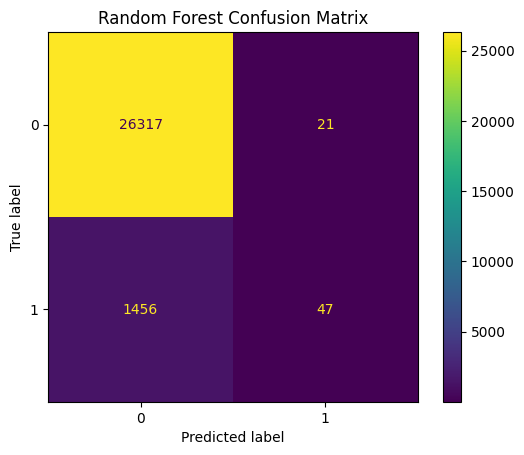

In [15]:
#Display Random Forest
ConfusionMatrixDisplay.from_predictions(y_val, forest_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

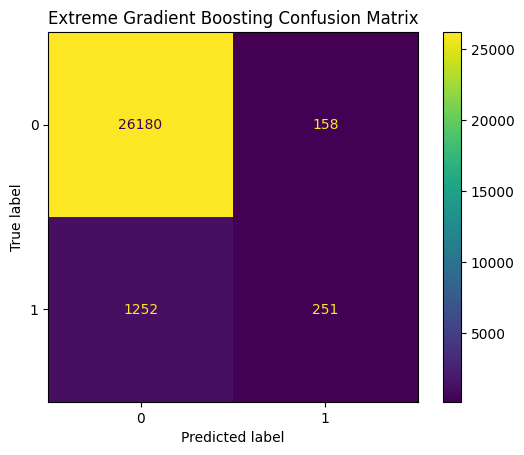

In [16]:
# XG GBoost
ex_model = xgb.XGBClassifier(n_estimators=100, random_state=42, max_depth=6, eval_metric='logloss')
ex_model.fit(X_train, y_train)
ex_pred = ex_model.predict(X_val)

#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_val,ex_pred)
plt.title("Extreme Gradient Boosting Confusion Matrix")
plt.show

Training Neural Network... Please wait.
871/871 [==============================] - 1s 511us/step


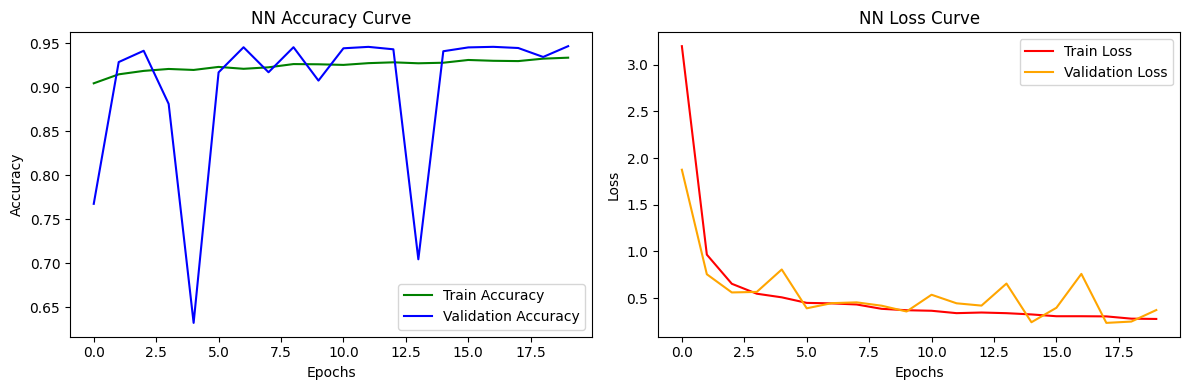

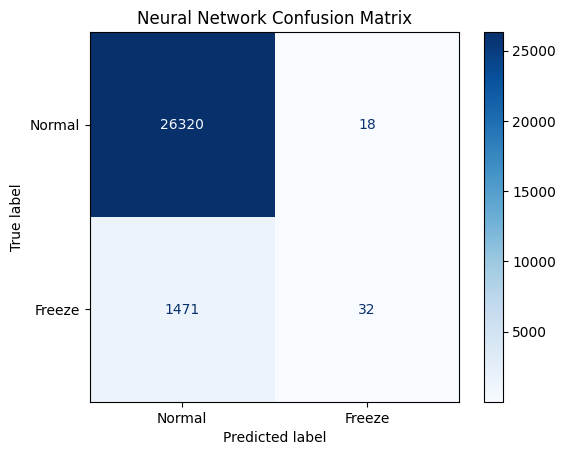

In [17]:
#NN
# Initialize the empty Sequential pipeline
nn_model = Sequential([
    # Input layer & Hidden layer combined
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)), 
    # Output layer (1 neuron, sigmoid for probability 0 to 1)
    Dense(1, activation='sigmoid') 
])

# Tell the network how to learn
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model and let Keras track the "Exams" automatically
print("Training Neural Network... Please wait.")
history = nn_model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), # Administers the Unseen Final Exam at each step
    epochs=20, 
    batch_size=32,
    verbose=0 # Hides the messy progress bar
)

# NNs output decimals (e.g., 0.85). We round them to 0 or 1 for the confusion matrix.
nn_probs = nn_model.predict(X_val)
nn_preds = (nn_probs > 0.5).astype(int)

# ==========================================
# 2. PLOT THE TRAINING & VALIDATION CURVES
# ==========================================
plt.figure(figsize=(12, 4))

# -- Accuracy Curve --
plt.subplot(1, 2, 1) # Left plot
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('NN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# -- Loss Curve --
plt.subplot(1, 2, 2) # Right plot
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('NN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 3. PLOT THE CONFUSION MATRIX
# ==========================================
ConfusionMatrixDisplay.from_predictions(y_val, nn_preds, display_labels=['Normal', 'Freeze'], cmap='Blues')
plt.title("Neural Network Confusion Matrix")
plt.show()